# T2: Modelagem Não Supervisionada: Dataset HCV

Este notebook aplica K-Means ao dataset HCV (Hepatitis C Virus), ignorando completamente os rótulos durante o agrupamento. O objetivo é investigar se há estrutura natural nos dados e discutir em que medida os clusters encontrados dialogam, ou não, com as classes conhecidas do problema.

## Passo 0: Criar Pasta de Figuras

Garantimos que a pasta `figuras/` existe para armazenar os gráficos gerados ao longo do notebook.

In [1]:
import os
os.makedirs('../figuras', exist_ok=True)

## Passo 1: Importações e Configuração

Importamos todas as bibliotecas necessárias e fixamos a semente de aleatoriedade em 42 para garantir reprodutibilidade.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Passo 2: Carregamento e Exploração dos Dados

Carregamos o dataset HCV a partir do arquivo CSV. A estrutura é idêntica à utilizada na parte supervisionada: 615 instâncias, 12 atributos e um rótulo categórico (`Category`).

In [3]:
df = pd.read_csv('../data/hcvdat0.csv', index_col=0, na_values='NA')

print("Shape:", df.shape)
print()
print(df.head())
print()
print("Distribuição das classes (antes da consolidação):")
print(df['Category'].value_counts())
print()
print("Valores ausentes por coluna:")
print(df.isnull().sum())

Shape: (615, 13)

        Category  Age Sex   ALB   ALP   ALT   AST   BIL    CHE  CHOL   CREA  \
1  0=Blood Donor   32   m  38.5  52.5   7.7  22.1   7.5   6.93  3.23  106.0   
2  0=Blood Donor   32   m  38.5  70.3  18.0  24.7   3.9  11.17  4.80   74.0   
3  0=Blood Donor   32   m  46.9  74.7  36.2  52.6   6.1   8.84  5.20   86.0   
4  0=Blood Donor   32   m  43.2  52.0  30.6  22.6  18.9   7.33  4.74   80.0   
5  0=Blood Donor   32   m  39.2  74.1  32.6  24.8   9.6   9.15  4.32   76.0   

    GGT  PROT  
1  12.1  69.0  
2  15.6  76.5  
3  33.2  79.3  
4  33.8  75.7  
5  29.9  68.7  

Distribuição das classes (antes da consolidação):
Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64

Valores ausentes por coluna:
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL      

## Passo 3: Pré-Processamento

O pré-processamento na trilha não supervisionada difere da supervisionada em um ponto crucial: **não há divisão em treino, validação e teste**. O K-Means é aplicado sobre todo o conjunto de dados, pois o objetivo é descobrir a estrutura global dos dados, e não generalizar para instâncias não vistas.

Os rótulos (`Category`) são separados logo no início e preservados apenas para **análise post-hoc**, eles nunca serão vistos pelo algoritmo de agrupamento.

### 3.1: Consolidação dos Rótulos e Separação de X e y_true

Aplicamos a mesma consolidação da trilha supervisionada: a classe `'0s=suspect Blood Donor'` (7 instâncias) é mesclada com `'0=Blood Donor'`. Os rótulos resultantes são preservados em `y_true` para análise posterior, mas **não serão usados pelo K-Means**.

In [4]:
mapa_classes = {
    '0=Blood Donor':          'Blood Donor',
    '0s=suspect Blood Donor': 'Blood Donor',
    '1=Hepatitis':            'Hepatitis',
    '2=Fibrosis':             'Fibrosis',
    '3=Cirrhosis':            'Cirrhosis',
}
df['Category'] = df['Category'].map(mapa_classes)

# y_true é preservado APENAS para análise post-hoc: o K-Means não o vê.
le = LabelEncoder()
y_true = le.fit_transform(df['Category'])
class_names = le.classes_

X = df.drop(columns=['Category'])

print("Classes e codificação:", dict(zip(class_names, le.transform(class_names))))
print()
print("Distribuição das classes após consolidação:")
print(df['Category'].value_counts())

Classes e codificação: {'Blood Donor': np.int64(0), 'Cirrhosis': np.int64(1), 'Fibrosis': np.int64(2), 'Hepatitis': np.int64(3)}

Distribuição das classes após consolidação:
Category
Blood Donor    540
Cirrhosis       30
Hepatitis       24
Fibrosis        21
Name: count, dtype: int64


### 3.2: Codificação do Atributo Categórico `Sex`

`Sex` é uma variável binária (`m`/`f`). A codificação numérica direta (`m=1`, `f=0`) não introduz relação de ordem espúria entre os dois únicos valores possíveis.

In [5]:
X = X.copy()
X['Sex'] = X['Sex'].map({'m': 1, 'f': 0})
print("Valores únicos em Sex após codificação:", X['Sex'].unique())

Valores únicos em Sex após codificação: [1 0]


### 3.3: Imputação de Valores Faltantes pela Mediana

Como utilizamos todo o conjunto de dados para o agrupamento, a mediana é calculada sobre todas as instâncias. A mediana é mais robusta a outliers do que a média, importante dado que atributos como `ALT`, `AST` e `GGT` podem ter valores muito elevados em pacientes com doença hepática avançada.

In [6]:
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

assert X_imp.isnull().sum().sum() == 0, "Ainda há NaN após imputação!"
print("Imputação concluída. Nenhum valor faltante restante.")

Imputação concluída. Nenhum valor faltante restante.


### 3.4: Normalização Min-Max

O K-Means usa distância euclidiana para atribuir instâncias aos centroides. Sem normalização, atributos com escalas maiores (como `CREA`, que pode chegar a centenas) dominariam o cálculo de distância e distorceriam os clusters. O `MinMaxScaler` projeta todos os atributos para o intervalo [0, 1].

In [7]:
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns)

print("Intervalo dos atributos após normalização:")
print(X_scaled.describe().loc[['min', 'max']].T)

Intervalo dos atributos após normalização:
      min  max
Age   0.0  1.0
Sex   0.0  1.0
ALB   0.0  1.0
ALP   0.0  1.0
ALT   0.0  1.0
AST   0.0  1.0
BIL   0.0  1.0
CHE   0.0  1.0
CHOL  0.0  1.0
CREA  0.0  1.0
GGT   0.0  1.0
PROT  0.0  1.0


## Passo 4: Escolha do Número de Clusters (k)

A definição de k é a principal decisão no K-Means. Utilizamos dois critérios complementares:
1. **Método do Cotovelo (Elbow):** observa a inércia (WCSS, *Within Cluster Sum of Squares*) em função de k. A queda na inércia diminui progressivamente; o ponto onde a melhora fica marginal (o "cotovelo") sugere um bom valor de k.
2. **Coeficiente de Silhouette:** mede, para cada instância, o quão bem ela se encaixa em seu cluster em comparação com o cluster mais próximo. Valores mais altos indicam clusters mais coesos e bem separados.

### 4.1: Método do Cotovelo (Inércia)

Executamos o K-Means para k de 1 a 10 e plotamos a inércia. O parâmetro `n_init=10` executa o algoritmo 10 vezes com inicializações distintas e retorna o melhor resultado, isso mitiga o impacto da inicialização aleatória dos centroides.

k= 1  ->  Inércia = 224.84
k= 2  ->  Inércia = 78.05
k= 3  ->  Inércia = 68.11
k= 4  ->  Inércia = 61.17
k= 5  ->  Inércia = 56.13
k= 6  ->  Inércia = 51.76
k= 7  ->  Inércia = 48.78
k= 8  ->  Inércia = 46.45
k= 9  ->  Inércia = 44.50


k=10  ->  Inércia = 43.31


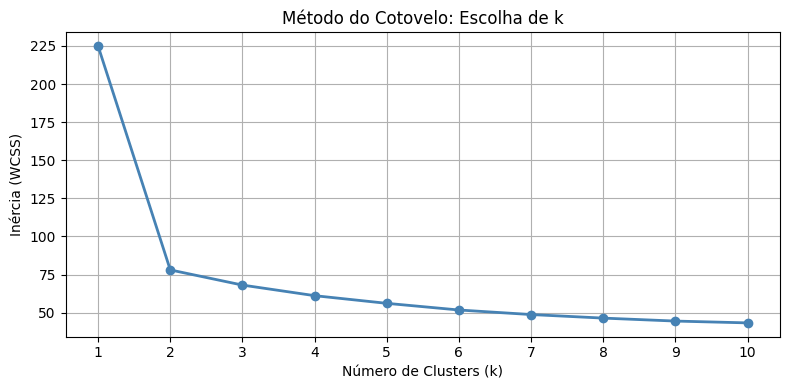

In [8]:
k_range = range(1, 11)
inercias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    print(f"k={k:2d}  ->  Inércia = {km.inertia_:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inercias, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo: Escolha de k')
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.savefig('../figuras/kmeans_cotovelo.png', dpi=150)
plt.show()

### 4.2: Coeficiente de Silhouette

Para cada k de 2 a 10, calculamos o Silhouette Score médio. O Silhouette Score é calculado por instância como:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
onde $a(i)$ é a distância média intra-cluster e $b(i)$ é a menor distância média para um cluster diferente. O score médio varia entre -1 e 1: valores próximos de 1 indicam boa separação e coesão.

k= 2  ->  Silhouette = 0.5989
k= 3  ->  Silhouette = 0.3867
k= 4  ->  Silhouette = 0.3643
k= 5  ->  Silhouette = 0.2109
k= 6  ->  Silhouette = 0.2037
k= 7  ->  Silhouette = 0.2062


k= 8  ->  Silhouette = 0.2118
k= 9  ->  Silhouette = 0.1996
k=10  ->  Silhouette = 0.1848

Melhor k pelo Silhouette: 2  (score = 0.5989)


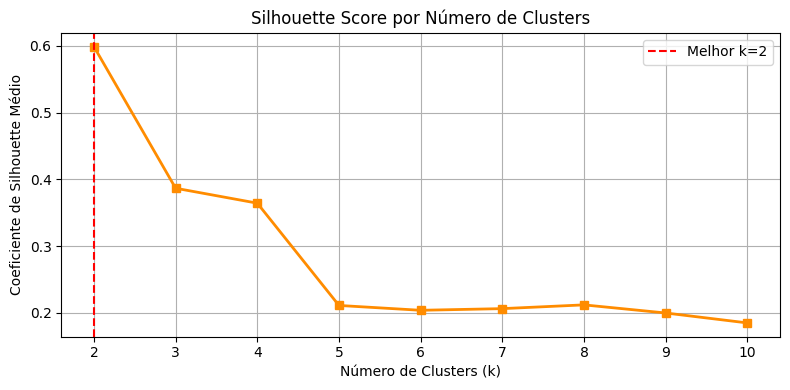

In [9]:
k_range_sil = range(2, 11)
silhouettes = []

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f"k={k:2d}  ->  Silhouette = {sil:.4f}")

melhor_k_sil = list(k_range_sil)[int(np.argmax(silhouettes))]
print(f"\nMelhor k pelo Silhouette: {melhor_k_sil}  (score = {max(silhouettes):.4f})")

plt.figure(figsize=(8, 4))
plt.plot(list(k_range_sil), silhouettes, marker='s', color='darkorange', linewidth=2)
plt.axvline(melhor_k_sil, color='red', linestyle='--', label=f'Melhor k={melhor_k_sil}')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette Médio')
plt.title('Silhouette Score por Número de Clusters')
plt.xticks(list(k_range_sil))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../figuras/kmeans_silhouette.png', dpi=150)
plt.show()

### 4.3: Decisão do Melhor k

Combinamos as evidências dos dois métodos para escolher k. Observamos também que o dataset possui **4 classes verdadeiras** (após consolidação): Blood Donor, Cirrhosis, Fibrosis e Hepatitis. Essa informação serve apenas como referência de comparação post-hoc, não é usada para guiar o agrupamento.

In [10]:
N_CLASSES_VERDADEIRAS = len(class_names)

# O melhor k é determinado pelo Silhouette Score (critério objetivo).
# Guardamos também k=4 (número de classes verdadeiras) para análise comparativa.
MELHOR_K = melhor_k_sil

print(f"k escolhido (Silhouette):       {MELHOR_K}")
print(f"k alternativo (classes reais):  {N_CLASSES_VERDADEIRAS}")
print(f"Classes verdadeiras: {list(class_names)}")

if MELHOR_K == N_CLASSES_VERDADEIRAS:
    print("\nO k escolhido coincide com o número de classes verdadeiras.")
else:
    print(f"\nO k escolhido ({MELHOR_K}) difere do número de classes verdadeiras ({N_CLASSES_VERDADEIRAS}).")
    print("Ambos serão analisados no Passo 9.")

k escolhido (Silhouette):       2
k alternativo (classes reais):  4
Classes verdadeiras: ['Blood Donor', 'Cirrhosis', 'Fibrosis', 'Hepatitis']

O k escolhido (2) difere do número de classes verdadeiras (4).
Ambos serão analisados no Passo 9.


## Passo 5: Treinamento do K-Means Final

Treinamos o K-Means com o k escolhido. `n_init=10` garante que o algoritmo seja executado 10 vezes com inicializações distintas e que o resultado com menor inércia seja retido. Isso mitiga o problema da sensibilidade à inicialização aleatória dos centroides.

In [11]:
kmeans = KMeans(n_clusters=MELHOR_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

inertia_final      = kmeans.inertia_
silhouette_final   = silhouette_score(X_scaled, cluster_labels)

print(f"K-Means treinado com k={MELHOR_K}")
print(f"Inércia final (WCSS): {inertia_final:.2f}")
print(f"Silhouette Score:     {silhouette_final:.4f}")
print()
print("Tamanho dos clusters:")
for c in range(MELHOR_K):
    n = int((cluster_labels == c).sum())
    print(f"  Cluster {c}: {n} instâncias ({n / len(cluster_labels) * 100:.1f}%)")

K-Means treinado com k=2
Inércia final (WCSS): 78.05
Silhouette Score:     0.5989

Tamanho dos clusters:
  Cluster 0: 377 instâncias (61.3%)
  Cluster 1: 238 instâncias (38.7%)


## Passo 6: Visualização dos Clusters com PCA

O dataset possui 12 dimensões, o que impossibilita visualização direta. Aplicamos PCA (Análise de Componentes Principais) para projetar os dados em 2D, preservando o máximo de variância possível.

Exibimos dois gráficos lado a lado:
- **Esquerda:** coloração pelos clusters encontrados pelo K-Means
- **Direita:** coloração pelos rótulos verdadeiros

A comparação visual permite observar em que medida os grupos descobertos dialogam com as classes reais.

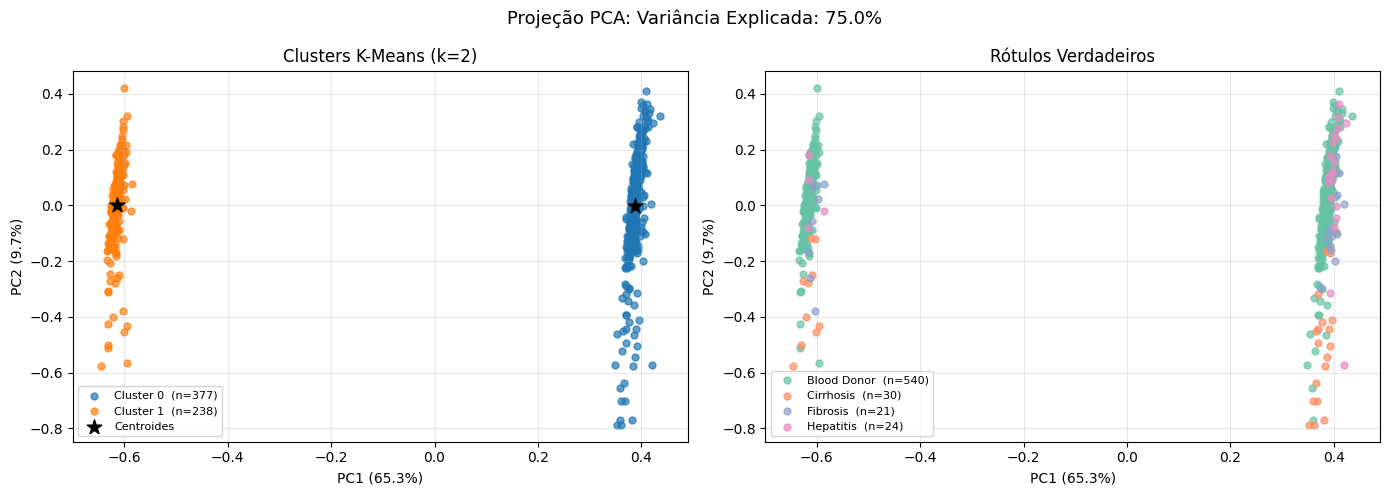

Variância explicada pelas 2 componentes principais: 75.0%


In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
variancia_explicada = pca.explained_variance_ratio_.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Esquerda: clusters K-Means ---
palette_clusters = sns.color_palette('tab10', MELHOR_K)
for c in range(MELHOR_K):
    mask = cluster_labels == c
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=25, alpha=0.7,
        label=f'Cluster {c}  (n={mask.sum()})',
        color=palette_clusters[c]
    )
# Centroides projetados em 2D
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=120, marker='*', color='black', zorder=5, label='Centroides'
)
axes[0].set_title(f'Clusters K-Means (k={MELHOR_K})')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Direita: rótulos verdadeiros ---
palette_true = sns.color_palette('Set2', len(class_names))
for i, nome in enumerate(class_names):
    mask = y_true == i
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=25, alpha=0.7,
        label=f'{nome}  (n={mask.sum()})',
        color=palette_true[i]
    )
axes[1].set_title('Rótulos Verdadeiros')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'Projeção PCA: Variância Explicada: {variancia_explicada:.1f}%',
    fontsize=13
)
plt.tight_layout()
plt.savefig('../figuras/kmeans_pca.png', dpi=150)
plt.show()

print(f"Variância explicada pelas 2 componentes principais: {variancia_explicada:.1f}%")

## Passo 7: Análise dos Clusters

Nesta seção analisamos os clusters a partir de três ângulos:
1. **Perfil dos centroides:** quais atributos caracterizam cada cluster?
2. **Tabela cruzada:** como as classes verdadeiras se distribuem entre os clusters?
3. **Adjusted Rand Index (ARI):** quão similar é o agrupamento encontrado à classificação verdadeira?

### 7.1: Perfil dos Centroides

Os centroides do K-Means representam o "paciente médio" de cada cluster no espaço normalizado. Desfazendo a normalização, obtemos valores na escala original dos marcadores, o que facilita a interpretação clínica.

O heatmap dos centroides normalizados permite comparar visualmente o perfil de cada cluster em relação a todos os atributos.

Valores dos centroides (escala original):
             Age  Sex    ALB    ALP    ALT    AST    BIL   CHE  CHOL   CREA    GGT   PROT
Cluster 0  47.21  1.0  42.29  67.82  31.71  38.22  13.13  8.49  5.34  87.59  45.32  72.26
Cluster 1  47.72  0.0  40.56  68.86  23.27  29.34   8.65  7.73  5.41  71.30  30.37  71.70


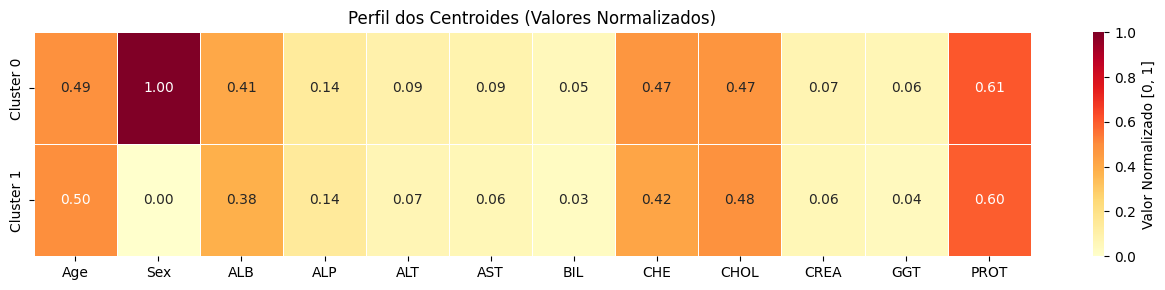

In [13]:
# Centroides na escala original (desfazendo a normalização)
centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns,
    index=[f'Cluster {i}' for i in range(MELHOR_K)]
)

print("Valores dos centroides (escala original):")
print(centroids_original.round(2).to_string())

# Heatmap dos centroides normalizados
centroids_normalized = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns,
    index=[f'Cluster {i}' for i in range(MELHOR_K)]
)

plt.figure(figsize=(13, max(3, MELHOR_K + 1)))
sns.heatmap(
    centroids_normalized,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Valor Normalizado [0, 1]'}
)
plt.title('Perfil dos Centroides (Valores Normalizados)')
plt.tight_layout()
plt.savefig('../figuras/kmeans_centroides.png', dpi=150)
plt.show()

### 7.2: Comparação com Rótulos Verdadeiros (Tabela Cruzada)

A tabela cruzada mostra quantas instâncias de cada classe verdadeira caíram em cada cluster. Um cluster "puro" seria aquele em que uma única classe domina amplamente. Essa análise permite interpretar qualitativamente o que cada cluster representa clinicamente.

Tabela Cruzada: Cluster × Classe Verdadeira
Classe Verdadeira  Blood Donor  Cirrhosis  Fibrosis  Hepatitis  All
Cluster 0                  324         20        13         20  377
Cluster 1                  216         10         8          4  238
Total                      540         30        21         24  615


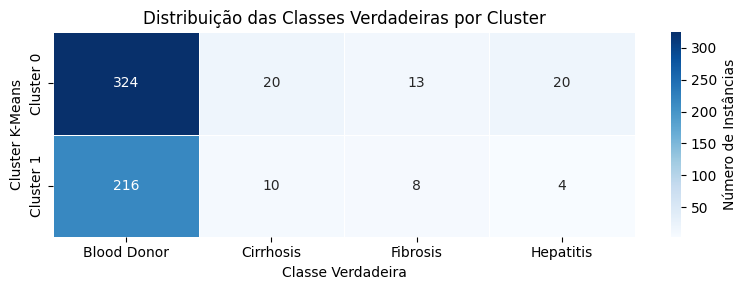

In [14]:
comparacao = pd.DataFrame({
    'Cluster': cluster_labels,
    'Classe Verdadeira': [class_names[i] for i in y_true]
})

tabela_cruzada = pd.crosstab(
    comparacao['Cluster'],
    comparacao['Classe Verdadeira'],
    margins=True
)
tabela_cruzada.index = (
    [f'Cluster {i}' for i in range(MELHOR_K)] + ['Total']
)

print("Tabela Cruzada: Cluster × Classe Verdadeira")
print(tabela_cruzada.to_string())

# Heatmap sem margens
tabela_sem_margem = pd.crosstab(
    comparacao['Cluster'],
    comparacao['Classe Verdadeira']
)
tabela_sem_margem.index = [f'Cluster {i}' for i in range(MELHOR_K)]

plt.figure(figsize=(8, max(3, MELHOR_K + 1)))
sns.heatmap(
    tabela_sem_margem,
    annot=True, fmt='d', cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Número de Instâncias'}
)
plt.title('Distribuição das Classes Verdadeiras por Cluster')
plt.xlabel('Classe Verdadeira')
plt.ylabel('Cluster K-Means')
plt.tight_layout()
plt.savefig('../figuras/kmeans_crosstab.png', dpi=150)
plt.show()

### 7.3: Adjusted Rand Index (ARI)

O ARI mede a concordância entre dois agrupamentos (o encontrado pelo K-Means e o verdadeiro), corrigindo para concordâncias que ocorreriam por acaso:
- **ARI = 1.0** → concordância perfeita com os rótulos verdadeiros
- **ARI ≈ 0.0** → concordância equivalente ao acaso
- **ARI < 0.0** → pior do que o acaso

É importante lembrar que valores baixos não necessariamente indicam que o K-Means "falhou", o agrupamento pode ter descoberto uma estrutura real e diferente da rotulagem original.

In [15]:
ari = adjusted_rand_score(y_true, cluster_labels)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print()
if ari >= 0.7:
    interpretacao = "Alta concordância com os rótulos verdadeiros."
elif ari >= 0.4:
    interpretacao = "Concordância moderada com os rótulos verdadeiros."
elif ari >= 0.1:
    interpretacao = "Baixa concordância com os rótulos verdadeiros."
else:
    interpretacao = "Concordância próxima ao acaso: os clusters não correspondem às classes verdadeiras."

print(f"Interpretação: {interpretacao}")

Adjusted Rand Index (ARI): -0.0168

Interpretação: Concordância próxima ao acaso: os clusters não correspondem às classes verdadeiras.


## Passo 8: Diagrama de Silhouette por Amostra

O diagrama de Silhouette por amostra mostra, para cada instância, o seu coeficiente de Silhouette individual agrupado por cluster. Clusters bem formados apresentam barras uniformemente positivas e próximas do valor médio. Barras negativas indicam instâncias que provavelmente pertencem a um cluster vizinho, o que sugere que a fronteira entre clusters não está bem definida.

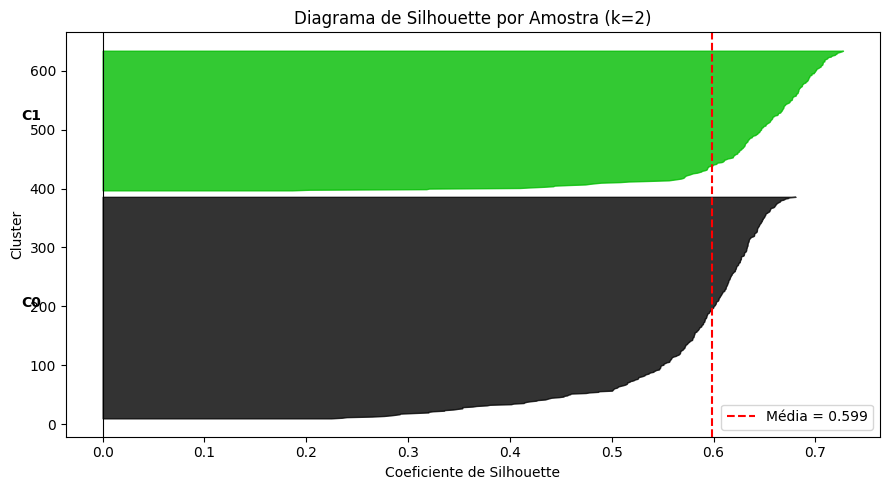

In [16]:
sample_silhouettes = silhouette_samples(X_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(9, max(5, MELHOR_K * 1.5 + 2)))
y_lower = 10

for c in range(MELHOR_K):
    cluster_sil = np.sort(sample_silhouettes[cluster_labels == c])
    size_c = len(cluster_sil)
    y_upper = y_lower + size_c
    color = plt.cm.nipy_spectral(float(c) / MELHOR_K)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, cluster_sil,
        facecolor=color, edgecolor=color, alpha=0.8
    )
    ax.text(-0.08, y_lower + 0.5 * size_c, f'C{c}', fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(
    x=silhouette_final, color='red', linestyle='--', linewidth=1.5,
    label=f'Média = {silhouette_final:.3f}'
)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_ylabel('Cluster')
ax.set_title(f'Diagrama de Silhouette por Amostra (k={MELHOR_K})')
ax.legend()
plt.tight_layout()
plt.savefig('../figuras/kmeans_silhouette_diagram.png', dpi=150)
plt.show()

## Passo 9: Experimento Complementar: k = Número de Classes Verdadeiras

Quando o k escolhido pelos critérios objetivos difere do número de classes verdadeiras (4), executamos também o K-Means com k=4 para comparação direta. Isso permite discutir: **o K-Means consegue recuperar as classes do problema quando é forçado a criar exatamente 4 grupos?**

Se já escolhemos k=4, esta seção confirma os resultados finais.

Executando K-Means com k=4 (número de classes verdadeiras)...
  k=4  Inércia=61.17  Silhouette=0.3643  ARI=0.0433

Tabela Comparativa (k escolhido vs. k=4):
 k  Inércia  Silhouette     ARI
 2  78.0521      0.5989 -0.0168
 4  61.1659      0.3643  0.0433


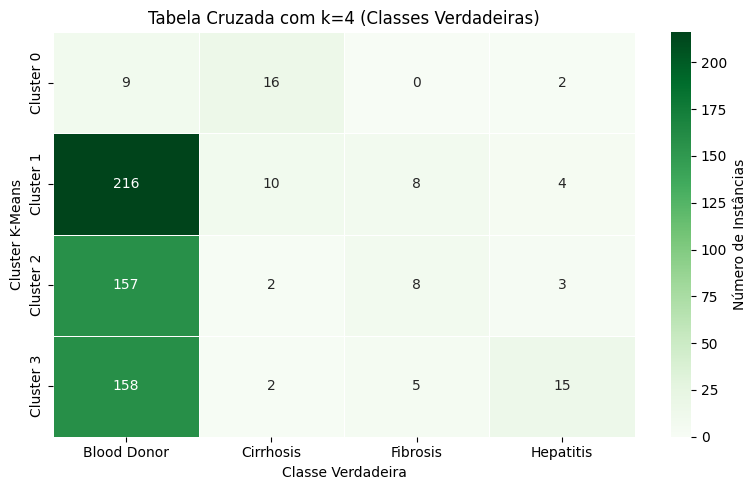

In [17]:
K_ALTERNATIVO = N_CLASSES_VERDADEIRAS  # k=4

if K_ALTERNATIVO != MELHOR_K:
    print(f"Executando K-Means com k={K_ALTERNATIVO} (número de classes verdadeiras)...")
    km_alt = KMeans(n_clusters=K_ALTERNATIVO, random_state=RANDOM_STATE, n_init=10)
    labels_alt = km_alt.fit_predict(X_scaled)

    inertia_alt    = km_alt.inertia_
    sil_alt        = silhouette_score(X_scaled, labels_alt)
    ari_alt        = adjusted_rand_score(y_true, labels_alt)

    print(f"  k={K_ALTERNATIVO}  Inércia={inertia_alt:.2f}  "
          f"Silhouette={sil_alt:.4f}  ARI={ari_alt:.4f}")
    print()

    # Tabela comparativa
    resumo = pd.DataFrame([
        {'k': MELHOR_K,    'Inércia': inertia_final,  'Silhouette': silhouette_final, 'ARI': ari},
        {'k': K_ALTERNATIVO, 'Inércia': inertia_alt,   'Silhouette': sil_alt,          'ARI': ari_alt},
    ])
    print("Tabela Comparativa (k escolhido vs. k=4):")
    print(resumo.round(4).to_string(index=False))

    # Tabela cruzada para k alternativo
    comp_alt = pd.DataFrame({
        'Cluster': labels_alt,
        'Classe Verdadeira': [class_names[i] for i in y_true]
    })
    tab_alt = pd.crosstab(comp_alt['Cluster'], comp_alt['Classe Verdadeira'])
    tab_alt.index = [f'Cluster {i}' for i in range(K_ALTERNATIVO)]

    plt.figure(figsize=(8, max(3, K_ALTERNATIVO + 1)))
    sns.heatmap(tab_alt, annot=True, fmt='d', cmap='Greens',
                linewidths=0.5, cbar_kws={'label': 'Número de Instâncias'})
    plt.title(f'Tabela Cruzada com k={K_ALTERNATIVO} (Classes Verdadeiras)')
    plt.xlabel('Classe Verdadeira')
    plt.ylabel('Cluster K-Means')
    plt.tight_layout()
    plt.savefig('../figuras/kmeans_crosstab_k4.png', dpi=150)
    plt.show()
else:
    print(f"O k escolhido ({MELHOR_K}) já coincide com o número de classes verdadeiras ({N_CLASSES_VERDADEIRAS}).")
    print("Os resultados do Passo 7 já representam esta análise.")
    print()
    resumo = pd.DataFrame([{
        'k': MELHOR_K,
        'Inércia': inertia_final,
        'Silhouette': silhouette_final,
        'ARI': ari
    }])
    print("Resumo das métricas finais:")
    print(resumo.round(4).to_string(index=False))

## Passo 10: Resumo das Métricas Finais

Consolidamos todas as métricas calculadas ao longo do notebook para facilitar a elaboração do relatório.

In [18]:
print("=" * 55)
print("  RESUMO FINAL: K-MEANS NO DATASET HCV")
print("=" * 55)
print(f"  Dataset:             {len(X_scaled)} instâncias, {X_scaled.shape[1]} atributos")
print(f"  k escolhido:         {MELHOR_K}")
print(f"  Inércia (WCSS):      {inertia_final:.2f}")
print(f"  Silhouette Score:    {silhouette_final:.4f}")
print(f"  Adjusted Rand Index: {ari:.4f}")
print()
print("Tamanho final dos clusters:")
for c in range(MELHOR_K):
    n = int((cluster_labels == c).sum())
    print(f"  Cluster {c}: {n} instâncias ({n / len(cluster_labels) * 100:.1f}%)")
print()
print("Classes verdadeiras (referência):")
for nome in class_names:
    n = int((df['Category'] == nome).sum())
    print(f"  {nome}: {n} instâncias ({n / len(df) * 100:.1f}%)")

  RESUMO FINAL: K-MEANS NO DATASET HCV
  Dataset:             615 instâncias, 12 atributos
  k escolhido:         2
  Inércia (WCSS):      78.05
  Silhouette Score:    0.5989
  Adjusted Rand Index: -0.0168

Tamanho final dos clusters:
  Cluster 0: 377 instâncias (61.3%)
  Cluster 1: 238 instâncias (38.7%)

Classes verdadeiras (referência):
  Blood Donor: 540 instâncias (87.8%)
  Cirrhosis: 30 instâncias (4.9%)
  Fibrosis: 21 instâncias (3.4%)
  Hepatitis: 24 instâncias (3.9%)
